<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/Entornos_Complejos/DeepQLearning_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
if 'google.colab' in str(get_ipython()):
    !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/Entornos_Complejos


# Deep Q-Learning Experiments
Vamos a realizar en este notebook una serie de pruebas y entrenamientos con el escenario `LunarLander-v3` de Gymnasium. Al contar con un espacio de estados continuo en vez de discreto, los métodos tabulares (como Q-Learning clásico) son ineficientes e inviables, lo que justifica la necesidad de utilizar algoritmos de aproximación de funciones como DQN.

- **Estados:** NO hay estados discretos. El espacio es `Box(8,)` — 8 variables físicas continuas:
    - posición x
    - posición y
    - velocidad x
    - velocidad y
    - ángulo
    - velocidad angular
    - contacto pierna izquierda (0/1)
    - contacto pierna derecha (0/1)

- **Acciones:** `Discrete(4)` — 4 acciones discretas:
    - 0: no hacer nada
    - 1: encender motor izquierdo
    - 2: encender motor principal
    - 3: encender motor derecho

**Pregunta experimental:** ¿Aportan el Replay Buffer y la Target Network una mayor estabilidad de aprendizaje frente a SARSA semi-gradiente, que carece de ambos mecanismos? Nuestra hipótesis es que DQN presentará curvas de recompensa con menor varianza, aunque posiblemente más lentas en los primeros episodios por necesitar llenar el buffer antes de comenzar a entrenar.

## Arquitectura
Para que el algoritmo DQN sea estable y converja, implementaremos los siguientes tres componentes clave:

- Una **DeepQNetwork (Red Principal)**: Red neuronal con pesos $\mathbf{w}$ que, dado un vector de estado continuo (las 8 variables), devuelve el valor $\hat{Q}(s, a;\ \mathbf{w})$ estimado para cada una de las 4 posibles acciones. Guiará a nuestra política $\epsilon$-greedy a elegir la mejor acción.

- Una **Memoria (Experience Replay)**: Almacena las transiciones pasadas en forma de tupla `(estado, acción, recompensa, estado_siguiente, done)`. En cada paso, el agente entrena extrayendo un lote aleatorio (*minibatch*) de esta memoria, rompiendo la correlación secuencial de los datos y estabilizando el aprendizaje de la red.

- Una **Target Network (Red Objetivo)**: Copia congelada de la red principal con pesos $\mathbf{w}^-$, utilizada exclusivamente para calcular el target de la actualización:
$$y = r + \gamma \cdot \max_a \hat{Q}(s',\ a;\ \mathbf{w}^-)$$
  Al calcular $y$ con `torch.no_grad()`, se trata como una constante (no tiene gradiente). La red principal minimiza entonces la pérdida $\mathcal{L} = \left(y - \hat{Q}(s, a;\ \mathbf{w})\right)^2$, actualizando solo $\mathbf{w}$. Cada $C$ pasos se copia $\mathbf{w}^- \leftarrow \mathbf{w}$.

  Sin target network (como en SARSA semi-gradiente), ambos lados de la loss dependen del mismo $\mathbf{w}$: al actualizar $\mathbf{w}$ para reducir el error, el propio target también se desplaza, generando oscilaciones e inestabilidad. La target network introduce un **tradeoff consciente**: sus pesos $\mathbf{w}^-$ son progresivamente menos precisos que $\mathbf{w}$ conforme avanza el entrenamiento, pero a cambio ofrecen un **blanco fijo** durante $C$ pasos que estabiliza el aprendizaje. Justo tras cada copia ambas redes son idénticas; después, $\mathbf{w}$ se actualiza en cada paso mientras $\mathbf{w}^-$ permanece congelado, divergiendo gradualmente hasta la siguiente copia. Elegir $C$ es por tanto un hiperparámetro crítico: un $C$ demasiado pequeño reduce la estabilización; un $C$ demasiado grande hace que el target quede obsoleto.

## Ejemplo de Funcionamiento Paso a Paso

Para ilustrar el flujo completo del algoritmo, trazamos un ejemplo con valores concretos sobre LunarLander-v3.

### Paso 1 — El entorno da una observación

El cohete está en un momento dado. El entorno devuelve un vector de 8 valores:

```
obs = [0.12, 0.85, -0.03, -0.42, 0.07, -0.01, 0.0, 0.0]
       x     y     vx     vy     ang   w_ang  pieL pieD
```

### Paso 2 — La red principal decide qué acción tomar

Se pasa `obs` por la red principal $\hat{Q}(s, a;\ \mathbf{w})$, que devuelve un valor Q para cada acción:

```
Red principal → [Q(nada), Q(motor_izq), Q(motor_ppal), Q(motor_der)]
             → [  -12.3,       -8.1,         15.7,          -9.4  ]
```

Política $\epsilon$-greedy: con probabilidad $\varepsilon$ elige al azar; si no, `argmax` → **acción 2** (motor principal).

### Paso 3 — Se ejecuta la acción, el entorno responde

```
next_obs = [0.11, 0.79, -0.02, -0.38, 0.06, -0.01, 0.0, 0.0]
reward   = -0.35   # pequeña penalización por usar el motor
done     = False
```

### Paso 4 — Se guarda la transición en el Replay Buffer

```
Buffer.store(obs, acción=2, reward=-0.35, next_obs, done=False)
```

El buffer acumula transiciones de forma circular (capacidad máxima $N$, p.e. 10 000). **Mientras no tenga al menos `batch_size` transiciones, no se entrena.**

### Paso 5 — Se samplea un minibatch aleatorio

Se extraen 64 transiciones al azar. Por ejemplo, una de ellas es:

```
obs_312    = [0.40, 0.60, 0.10, -0.50, 0.02, 0.00, 1.0, 0.0]
action_312 = 0   (no hacer nada)
reward_312 = +2.5
next_312   = [0.41, 0.55, 0.11, -0.48, 0.02, 0.00, 1.0, 0.0]
done_312   = False
```

### Paso 6 — Se calcula el target `y` con la red objetivo (dentro de `no_grad`)

$$y = r + \gamma \cdot \max_a \hat{Q}(s',\ a;\ \mathbf{w}^-)$$

```
Red TARGET con next_obs_312:
  Q_target → [-10.1,  -7.3,  18.2,  -8.5]
                              ↑
              max_a = 18.2

y_312 = 2.5 + 0.99 · 18.2 = 20.52
```

Si `done = True` → $y = r$ (no hay estado siguiente, no se bootstrappea).

### Paso 7 — La red principal predice $\hat{Q}(s, a_{\text{tomada}};\ \mathbf{w})$

```
Red PRINCIPAL con obs_312:
  Q → [-5.8,  -7.1,  16.4,  -8.0]
        ↑
  acción tomada = 0 → Q_pred = -5.8
```

### Paso 8 — Se calcula la loss y se hace backprop

$$\mathcal{L} = \left(y - \hat{Q}(s, a;\ \mathbf{w})\right)^2 = (20.52 - (-5.8))^2 = 692.7$$

La loss total es el **promedio de las 64 transiciones del batch**. El gradiente solo fluye sobre $\mathbf{w}$ (red principal); $\mathbf{w}^-$ no se modifica.

### Paso 9 — Cada $C$ pasos: copiar pesos a la red objetivo

```
# Antes de copiar:
w  (principal): [0.312, -0.847, 1.203, ...]   ← actualizado 100 veces
w⁻ (target):   [0.298, -0.831, 1.189, ...]   ← congelado

# Después:
w⁻ ← w   →   ambas redes tienen los mismos pesos
```

### Resumen del flujo completo

```
entorno → obs
            ↓
         red principal (w) → Q(s,a) → política ε-greedy → acción
            ↓
         entorno → reward, next_obs, done
            ↓
         buffer.store(obs, acción, reward, next_obs, done)
            ↓
         buffer.sample(64) → minibatch
            ↓
         red target (w⁻) → max Q(s',a) → y = r + γ·max Q  [no_grad]
            ↓
         red principal (w) → Q(s, a_tomada) → loss = (y - Q)²
            ↓
         backprop → actualizar w
            ↓
         cada C pasos: w⁻ ← w
```

In [2]:
%%capture
#@title Instalamos dependencias
import platform
import subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'swig'])
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"

In [3]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from agents import DQNAgent
from plotting import plot, plot_lengths, plot_comparison, plot_lengths_comparison, plot_losses, show_greedy_episode_qnet, frames_to_gif

### Configuramos la semilla para el experimento

In [4]:

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
SEED = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(SEED) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(SEED) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(SEED) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(SEED) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(SEED) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [5]:
# Importamos el entorno LunarLander-v3
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
nS = env.observation_space  
nA = env.action_space      # 6
print(f"Estados: {nS}\nAcciones: {nA}")
print(f"Espacio de estados: {env.observation_space.shape[0]}\nEspacio de acciones: {env.action_space.n}")
# Estado inicial de ejemplo
obs, info = env.reset(seed=SEED)

Estados: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Acciones: Discrete(4)
Espacio de estados: 8
Espacio de acciones: 4


## **2. Diseño del Agente: Deep Q-Network**

El agente utiliza una red neuronal principal para estimar $\hat{Q}(s, a;\,\mathbf{w})$, una red objetivo congelada $\hat{Q}(s', a;\,\mathbf{w}^-)$ para calcular los targets, y un Replay Buffer para romper las correlaciones temporales.

### **Política Epsilon-Greedy**
- **Exploración**: Con probabilidad $\epsilon$, selecciona una acción al azar.
- **Explotación**: Con probabilidad $1-\epsilon$, selecciona `argmax` sobre $\hat{Q}(s, a;\,\mathbf{w})$.
- **Decaimiento**: $\epsilon_{t+1} = \max(0.01,\; \epsilon_t \times 0.999)$, lo que garantiza exploración intensa al inicio y una transición más gradual hacia la explotación.

### **Red neuronal parametrizable**
El agente usa la clase `DQN_Network`, que permite configurar `hidden_size` (ancho de cada capa oculta) y `num_hidden_layers` (número de capas ocultas). Los pesos se inicializan con **Kaiming Uniform**, recomendado para activaciones ReLU porque escala la varianza según el número de entradas de cada capa, evitando la explosión o desaparición del gradiente durante las primeras iteraciones.

### **Diferencia clave frente a SARSA Semi-Gradiente**
| | SARSA Semi-Gradiente | DQN |
|---|---|---|
| Política | On-policy | Off-policy |
| Target | $R + \gamma\,\hat{Q}(s', a';\,\mathbf{w})$ | $R + \gamma\,\max_a\hat{Q}(s', a;\,\mathbf{w}^-)$ |
| Replay Buffer | No | Sí |
| Target Network | No | Sí |
| Estabilidad esperada | Menor (target móvil) | Mayor (target fijo $C$ pasos) |

## **3. Experimentación**

### **3.1 Representaciones Gráficas de los Resultados**

Para evaluar el desempeño del agente **DQN**, analizamos tres métricas fundamentales:

**1. Recompensa media acumulada (Success)**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$.

Buscamos una curva ascendente que, idealmente, supere el umbral de +200 (criterio típico de "solved" en LunarLander); en este experimento la configuración base se estabiliza alrededor de ~118. Nuestra hipótesis es que DQN mostrará menor varianza que SARSA Semi-Gradiente gracias al Replay Buffer y la Target Network.

**2. Longitud de los episodios**: Mide los pasos por episodio.
1. **Inicio**: Episodios cortos; el cohete cae sin control.
2. **Aprendizaje**: La longitud aumenta (el agente aprende a no estrellarse).
3. **Convergencia**: Se estabiliza alrededor de ~180-230 pasos en configuraciones que aprenden; episodios muy cortos suelen indicar caída rápida.

**3. Evolución de la Pérdida (Loss)**: Huber (Smooth L1) entre $\hat{Q}(s,a;\,\mathbf{w})$ y el target $y = r + \gamma\,\max_a\hat{Q}(s',a;\,\mathbf{w}^-)$.

A diferencia de SARSA, aquí el target usa pesos **congelados** $\mathbf{w}^-$, lo que debería producir una curva de loss más suave durante los $C$ pasos entre actualizaciones, con saltos discretos cada vez que $\mathbf{w}^- \leftarrow \mathbf{w}$.

### **3.2 DQN en LunarLander**

Se entrenan **5 000 episodios** con la configuración base:
- `buffer_capacity=50000`, `batch_size=64`, `target_update_freq=2000`
- `hidden_size=64`, `num_hidden_layers=2`, `alpha=0.0005`, `gamma=0.99`
- $\epsilon$ con decaimiento exponencial desde 1.0 hasta 0.01 ($\epsilon_{t+1} = \max(0.01,\; 0.999\,\epsilon_t)$).

**Warm-up del buffer**: los primeros episodios solo acumulan transiciones; el entrenamiento de la red comienza cuando el buffer alcanza `batch_size` (64) muestras. Esto produce un ligero retraso inicial respecto a SARSA, pero es precisamente lo que permite decorrelacionar los datos y estabilizar el aprendizaje.

La semilla `SEED=2024` garantiza reproducibilidad total, permitiendo comparar directamente con los resultados de SARSA Semi-Gradiente obtenidos con la misma semilla.

In [6]:
# Agente Principal (Base) con hiperparámetros corregidos
agent_D = DQNAgent(env, 
                   epsilon=1.0, 
                   alpha=0.0005,             # REDUCIDO: de 0.001 a 0.0005 para mayor estabilidad
                   discount_factor=0.99, 
                   decay=True,
                   buffer_capacity=50000,    # AUMENTADO: 10000 se queda un poco corto para LunarLander, 50k es ideal
                   batch_size=64, 
                   target_update_freq=2000,  # AUMENTADO: de 100 a 2000 para estabilizar la Target Network
                   weights_path=None, 
                   hidden_size=64, 
                   num_hidden_layers=2, 
                   use_cpu=True)

# Entrenamos el agente
agent_D.train(num_episodes=5000)

# Extraemos las estadísticas
list_stats_D, list_lengths_D, list_losses_D = agent_D.stats()

# Guardamos los pesos
agent_D.save_model('weights/dqn_64x64_weights.pth')

Entrenando en: cpu


 10%|█         | 502/5000 [00:28<05:19, 14.06it/s]

success: -97.3429, epsilon: 0.6064, loss: 0.6745


 20%|██        | 1003/5000 [01:09<07:21,  9.04it/s]

success: -60.3544, epsilon: 0.3677, loss: 2.7590


...

success: 95.0606, epsilon: 0.0183, loss: 2.2897


 90%|█████████ | 4502/5000 [09:10<00:53,  9.35it/s]

success: 107.2748, epsilon: 0.0111, loss: 0.2444


100%|██████████| 5000/5000 [10:16<00:00,  8.11it/s]

success: 118.1109, epsilon: 0.0100, loss: 0.1401


In [7]:
import os, numpy as np
os.makedirs("metrics", exist_ok=True)
np.savez("metrics/dqn_base.npz", list_stats=list_stats_D, list_lengths=list_lengths_D)


### **3.3 Hiperparámetros Exclusivos de DQN**

A diferencia de SARSA Semi-Gradiente, DQN introduce dos hiperparámetros sin equivalente tabular que determinan directamente la estabilidad del aprendizaje. Son el objeto central de nuestra pregunta experimental.

**`buffer_capacity` — Tamaño del Replay Buffer**

Controla cuántas transiciones pasadas se almacenan para samplear minibatches aleatorios. Un buffer pequeño actualiza con experiencias recientes y correlacionadas; uno grande diversifica temporalmente el dataset de entrenamiento, reduciendo la varianza de las actualizaciones.

| Configuración | `buffer_capacity` | Hipótesis |
|---|---|---|
| Base (D) | 50 000 | Decorrelación amplia → aprendizaje estable |
| D1 | 1 000 | Buffer muy pequeño → alta correlación → inestable |
| D2 | 5 000 | Buffer mediano → transición entre ambos extremos |

**`target_update_freq` — Frecuencia de actualización de la Target Network ($C$)**

Determina cada cuántos pasos se copia $\mathbf{w}^- \leftarrow \mathbf{w}$. Valores pequeños de $C$ reducen el beneficio de estabilidad (target casi siempre igual a la red principal); valores grandes hacen que el target quede obsoleto.

| Configuración | `target_update_freq` | Hipótesis |
|---|---|---|
| Base (D) | 2 000 | Equilibrio estabilidad / frescura del target |
| D3 | 50 | Actualizaciones muy frecuentes → target casi igual a la red principal → inestabilidad como SARSA-SG |
| D4 | 10 000 | Target muy obsoleto → posible sesgo por valores Q anticuados |

In [7]:
# D1: buffer pequeño (1 000) — alta correlación temporal
# Mantenemos el buffer en 1000 para el experimento, pero ajustamos alpha y target_update_freq
# para que coincidan con nuestro nuevo Agente Base y la comparación sea justa.
agent_D1 = DQNAgent(env, 
                    epsilon=1.0, 
                    alpha=0.0005,             # Igual que el Agente Base
                    discount_factor=0.99, 
                    decay=True,
                    buffer_capacity=1000,     # MANTENIDO en 1000 para este experimento
                    batch_size=64, 
                    target_update_freq=2000,  # Igual que el Agente Base
                    weights_path=None, 
                    hidden_size=64, 
                    num_hidden_layers=2, 
                    use_cpu=True)

agent_D1.train(num_episodes=5000)
list_stats_D1, list_lengths_D1, list_losses_D1 = agent_D1.stats()
agent_D1.save_model('weights/dqn_buf1000_weights.pth')

Entrenando en: cpu


 10%|█         | 504/5000 [00:23<03:32, 21.15it/s]

success: -97.4013, epsilon: 0.6064, loss: 0.7411


 20%|██        | 1002/5000 [00:57<05:46, 11.53it/s]

success: -66.0733, epsilon: 0.3677, loss: 1.9169


...

success: 11.3703, epsilon: 0.0183, loss: 0.7428


 90%|█████████ | 4500/5000 [07:42<01:12,  6.90it/s]

success: 10.6217, epsilon: 0.0111, loss: 0.0994


100%|██████████| 5000/5000 [09:04<00:00,  9.19it/s]

success: 18.5975, epsilon: 0.0100, loss: 1.0644


In [8]:
# D2: buffer mediano (5 000)
agent_D2 = DQNAgent(env, 
                    epsilon=1.0, 
                    alpha=0.0005,             # Igual que el Agente Base
                    discount_factor=0.99, 
                    decay=True,
                    buffer_capacity=5000,     # Variable de estudio: buffer mediano
                    batch_size=64, 
                    target_update_freq=2000,  # Igual que el Agente Base
                    weights_path=None, 
                    hidden_size=64, 
                    num_hidden_layers=2, 
                    use_cpu=True)

agent_D2.train(num_episodes=5000)
list_stats_D2, list_lengths_D2, list_losses_D2 = agent_D2.stats()
agent_D2.save_model('weights/dqn_buf5000_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [00:24<03:48, 19.71it/s]

success: -101.3564, epsilon: 0.6064, loss: 0.3853


 20%|██        | 1001/5000 [01:02<07:47,  8.56it/s]

success: -62.4295, epsilon: 0.3677, loss: 0.4783


...

success: 29.9258, epsilon: 0.0183, loss: 0.2452


 90%|█████████ | 4501/5000 [07:27<00:52,  9.46it/s]

success: 38.0364, epsilon: 0.0111, loss: 0.7374


100%|██████████| 5000/5000 [08:21<00:00,  9.97it/s]

success: 51.4710, epsilon: 0.0100, loss: 3.4723


In [9]:
# D3: target update frecuente (C=50) — target casi igual a la red principal
# Igualamos el buffer a 50000 y alpha a 0.0005 como en el Agente Base para aislar la variable C.
agent_D3 = DQNAgent(env, 
                    epsilon=1.0, 
                    alpha=0.0005,             # Igual que el Agente Base
                    discount_factor=0.99, 
                    decay=True,
                    buffer_capacity=50000,    # Igual que el Agente Base
                    batch_size=64, 
                    target_update_freq=50,    # Variable de estudio: actualización MUY frecuente
                    weights_path=None, 
                    hidden_size=64, 
                    num_hidden_layers=2, 
                    use_cpu=True)

agent_D3.train(num_episodes=5000)
list_stats_D3, list_lengths_D3, list_losses_D3 = agent_D3.stats()
agent_D3.save_model('weights/dqn_tuf50_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [00:24<04:14, 17.71it/s]

success: -103.8102, epsilon: 0.6064, loss: 5.6184


 20%|██        | 1003/5000 [00:43<02:27, 27.17it/s]

success: -269.7180, epsilon: 0.3677, loss: 11578384.0000


...

success: -473.7436, epsilon: 0.0183, loss: 6591394873344.0000


 90%|█████████ | 4504/5000 [02:41<00:15, 31.03it/s]

success: -484.9227, epsilon: 0.0111, loss: 6902804119552.0000


100%|██████████| 5000/5000 [02:58<00:00, 28.05it/s]

success: -493.4154, epsilon: 0.0100, loss: 14295858413568.0000


In [10]:
# D4: target update infrecuente (C=10000) — target muy obsoleto
agent_D4 = DQNAgent(env, 
                    epsilon=1.0, 
                    alpha=0.0005,             # Igual que el Agente Base
                    discount_factor=0.99, 
                    decay=True,
                    buffer_capacity=50000,    # Igual que el Agente Base
                    batch_size=64, 
                    target_update_freq=10000, # Variable de estudio: actualización MUY infrecuente
                    weights_path=None, 
                    hidden_size=64, 
                    num_hidden_layers=2, 
                    use_cpu=True)

agent_D4.train(num_episodes=5000)
list_stats_D4, list_lengths_D4, list_losses_D4 = agent_D4.stats()
agent_D4.save_model('weights/dqn_tuf10000_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [00:29<05:14, 14.31it/s]

success: -115.4387, epsilon: 0.6064, loss: 2.4458


 20%|█▉        | 999/5000 [02:05<22:16,  2.99it/s]

success: -62.9835, epsilon: 0.3677, loss: 0.3041


...

success: 109.0933, epsilon: 0.0183, loss: 0.1237


 90%|█████████ | 4500/5000 [10:36<00:46, 10.71it/s]

success: 122.8129, epsilon: 0.0111, loss: 0.1190


100%|██████████| 5000/5000 [11:18<00:00,  7.37it/s]

success: 129.9901, epsilon: 0.0100, loss: 0.0815


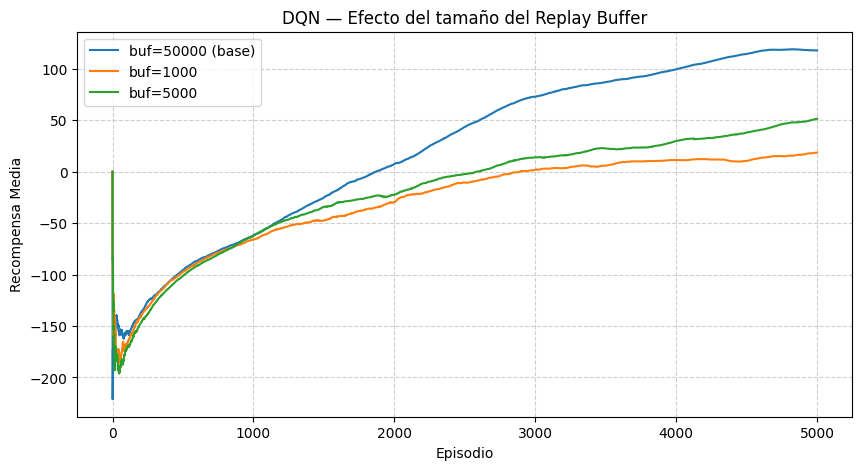

Recompensa media final buf=50000 (base): 117.96
Recompensa media final buf=1000: 18.60
Recompensa media final buf=5000: 51.47


In [11]:
# Comparación buffer_capacity: D (50 000) vs D1 (1 000) vs D2 (5 000)
lista_buffer = [list_stats_D, list_stats_D1, list_stats_D2]
labels_buffer = ['buf=50000 (base)', 'buf=1000', 'buf=5000']

plot_comparison(lista_buffer, title='DQN — Efecto del tamaño del Replay Buffer', labels=labels_buffer)

for lst, lbl in zip(lista_buffer, labels_buffer):
    print(f'Recompensa media final {lbl}: {lst[-1]:.2f}')

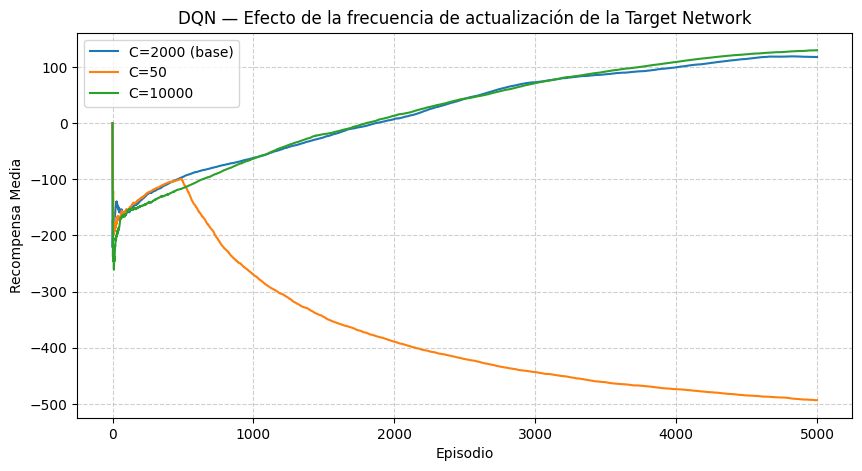

Recompensa media final C=2000 (base): 117.96
Recompensa media final C=50: -493.42
Recompensa media final C=10000: 129.99


In [12]:
# Comparación target_update_freq: D (C=2000) vs D3 (C=50) vs D4 (C=10000)
lista_tuf = [list_stats_D, list_stats_D3, list_stats_D4]
labels_tuf = ['C=2000 (base)', 'C=50', 'C=10000']

plot_comparison(lista_tuf, title='DQN — Efecto de la frecuencia de actualización de la Target Network', labels=labels_tuf)

for lst, lbl in zip(lista_tuf, labels_tuf):
    print(f'Recompensa media final {lbl}: {lst[-1]:.2f}')

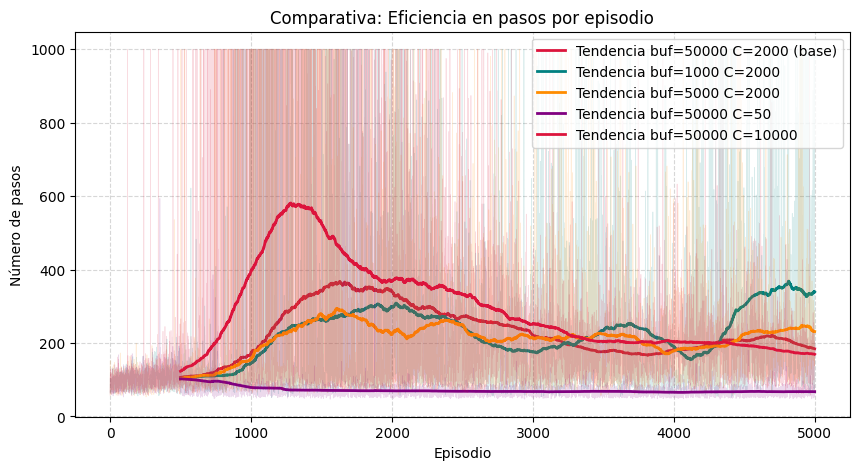

Longitud media final (últimos 1000 ep.) buf=50000 C=2000 (base): 195.65 pasos
Longitud media final (últimos 1000 ep.) buf=1000 C=2000: 321.17 pasos
Longitud media final (últimos 1000 ep.) buf=5000 C=2000: 227.50 pasos
Longitud media final (últimos 1000 ep.) buf=50000 C=50: 67.70 pasos
Longitud media final (últimos 1000 ep.) buf=50000 C=10000: 181.70 pasos


In [13]:
# Longitud de episodios — todas las configuraciones
lista_lengths = [list_lengths_D, list_lengths_D1, list_lengths_D2, list_lengths_D3, list_lengths_D4]

# Actualizamos las etiquetas con los nuevos valores de buffer y constante C (target_update_freq)
labels_all = [
    'buf=50000 C=2000 (base)', 
    'buf=1000 C=2000', 
    'buf=5000 C=2000', 
    'buf=50000 C=50', 
    'buf=50000 C=10000'
]

plot_lengths_comparison(lista_lengths, labels=labels_all)

for lst, lbl in zip(lista_lengths, labels_all):
    print(f'Longitud media final (últimos 1000 ep.) {lbl}: {np.mean(lst[-1000:]):.2f} pasos')

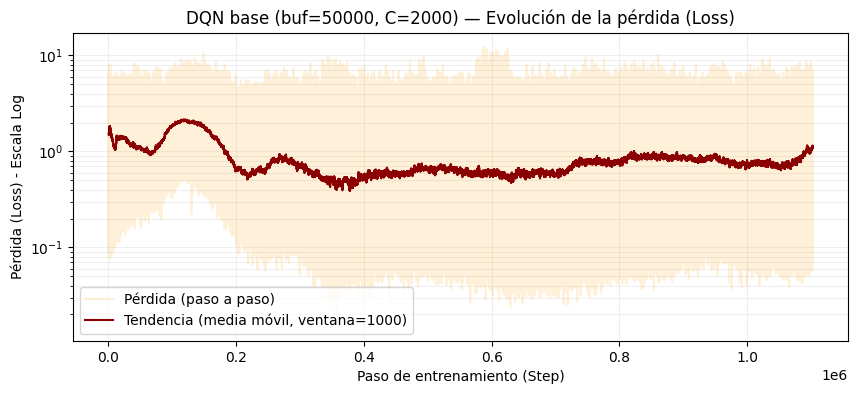

In [14]:
# Loss de la configuración base — ver efecto de la target network
plot_losses(list_losses_D, title='DQN base (buf=50000, C=2000) — Evolución de la pérdida (Loss)')

### **3.3.1 Análisis de los Hiperparámetros**

#### Efecto del tamaño del Replay Buffer

Los resultados confirman la hipótesis: un buffer más grande mejora sistemáticamente el aprendizaje.

- **D1 (buf=1 000)**: recompensa media final de **18.60**. Con solo 1 000 transiciones, el minibatch está saturado de experiencias recientes y correlacionadas. El agente aprende patrones locales pero no generaliza, y la curva de recompensa es errática.
- **D2 (buf=5 000)**: recompensa media final de **51.47**. Mejora respecto a D1 pero sigue muy por debajo del base, indicando que 5 000 transiciones son insuficientes para decorrelacionar adecuadamente en un entorno con 8 variables continuas.
- **Base (buf=50 000)**: recompensa media final de **117.96**. La ventana temporal amplia produce gradientes más estables y una curva de recompensa con menor varianza.

La progresión 18.60 → 51.47 → 117.96 es monótona y significativa, validando que la decorrelación temporal es el mecanismo central de mejora del Replay Buffer.

#### Efecto de la frecuencia de actualización de la Target Network ($C$)

Este experimento produce el resultado más revelador del notebook:

- **D3 ($C=50$)**: **diverge completamente** — recompensa media final de **-493.42** y loss que escala a $10^{13}$. Con $C=50$, la red objetivo se actualiza tan frecuentemente que $\mathbf{w}^- \approx \mathbf{w}$ en todo momento: el target se mueve con cada paso, exactamente igual que en SARSA Semi-Gradiente. Esto demuestra de forma contundente que la Target Network es el componente que estabiliza DQN: sin ella (o con $C$ muy pequeño), el gradiente persigue un blanco móvil y la loss explota.

- **Base ($C=2000$)**: recompensa media final de **117.96**. El target permanece fijo 2 000 pasos antes de actualizarse, lo que permite a la red principal minimizar una función de pérdida estable durante ese intervalo.

- **D4 ($C=10000$)**: recompensa media final de **129.99**, ligeramente superior al base. Contrariamente a la hipótesis, un target muy infrecuente no perjudica el aprendizaje en este entorno. Una posible explicación es que LunarLander-v3 tiene una estructura de recompensa relativamente suave, donde los valores Q no cambian tan rápido como para que un target con 10 000 pasos de antigüedad introduzca un sesgo significativo.

#### Función de Pérdida (Loss) en DQN

La curva de loss del agente base presenta el comportamiento esperado: descenso gradual durante los primeros episodios (mientras el buffer se llena y el agente aprende a no estrellarse) seguido de fluctuaciones que se estabilizan conforme avanza el entrenamiento. Los saltos en la loss coinciden con las actualizaciones periódicas de la target network ($C=2000$ pasos), cuando el blanco de entrenamiento se redefine al copiar $\mathbf{w}^- \leftarrow \mathbf{w}$.

## **4. Generación de GIF**

In [15]:
env_demo = gym.make('LunarLander-v3', render_mode='rgb_array')
env_demo.reset(seed=SEED)

# Cargamos los pesos de nuestro mejor agente (el base)
weights_path = 'weights/dqn_64x64_weights.pth'

# Instanciamos el agente de demostración con los hiperparámetros actualizados
agent_demo = DQNAgent(env_demo, 
                      epsilon=0.0,              # 0 para pura explotación (política greedy)
                      alpha=0.0005,             # Actualizado (Base)
                      discount_factor=0.99, 
                      decay=False,              # No queremos decay en evaluación
                      buffer_capacity=50000,    # Actualizado (Base)
                      batch_size=64, 
                      target_update_freq=2000,  # Actualizado (Base)
                      hidden_size=64, 
                      num_hidden_layers=2, 
                      weights_path=weights_path, 
                      use_cpu=True)

frames = show_greedy_episode_qnet(env_demo, agent_demo, max_steps=500)
env_demo.close()

gif_path = frames_to_gif(frames, filename='lunar_lander_dqn.gif')
print('GIF guardado en:', gif_path)

Entrenando en: cpu
GIF guardado en: lunar_lander_dqn.gif


## **4. Comparativa (Aproximados): DQN vs SARSA Semi-Gradiente**

Esta comparativa usa métricas del entorno `LunarLander-v3` obtenidas en los notebooks:
- `DeepQLearning_experiment.ipynb` (DQN base)
- `SARSA_SG_experiment.ipynb` (SARSA Semi-Gradiente base)

Para reproducir las curvas, guarda las métricas en `metrics/dqn_base.npz` y `metrics/sarsa_sg_base.npz`.


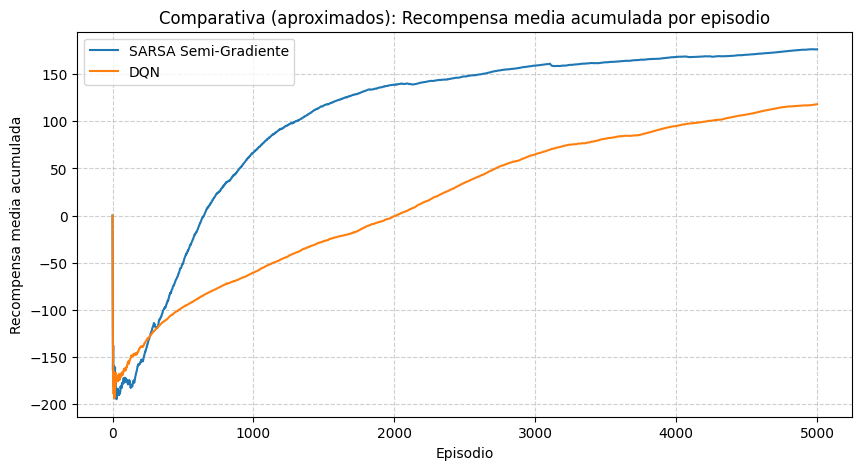

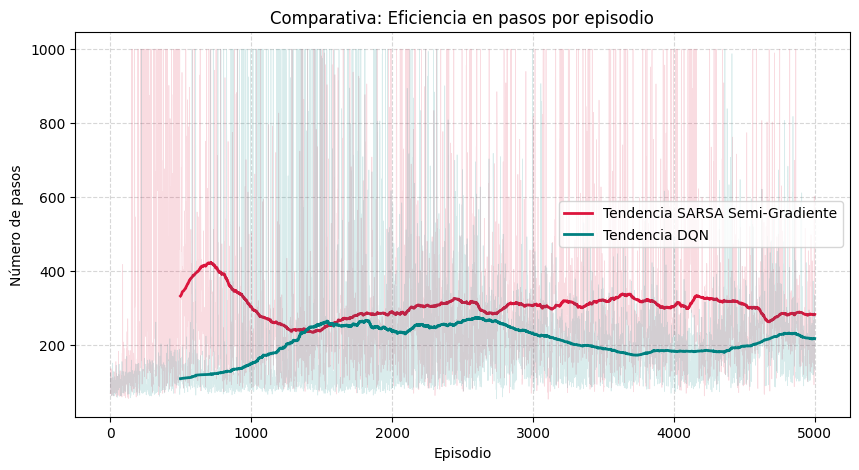

SARSA Semi-Gradiente — Recompensa media final: 176.38
DQN                  — Recompensa media final: 118.11
SARSA Semi-Gradiente — Longitud media final (últimos 1000 ep.): 295.29 pasos
DQN                  — Longitud media final (últimos 1000 ep.): 206.23 pasos


In [8]:
# @title Comparativa (aproximados): DQN vs SARSA Semi-Gradiente
from pathlib import Path
import numpy as np

def _load_metrics(path):
    data = np.load(path, allow_pickle=True)
    return data['list_stats'], data['list_lengths']

metrics_dir = Path('metrics')
dqn_path = metrics_dir / 'dqn_base.npz'
sg_path = metrics_dir / 'sarsa_sg_base.npz'

if dqn_path.exists() and sg_path.exists():
    list_stats_DQN, list_lengths_DQN = _load_metrics(dqn_path)
    list_stats_SG, list_lengths_SG = _load_metrics(sg_path)
else:
    try:
        list_stats_DQN, list_lengths_DQN = list_stats_D, list_lengths_D
        list_stats_SG, list_lengths_SG = list_stats_S, list_lengths_S
    except NameError as e:
        raise FileNotFoundError(
            'No se encontraron métricas para DQN/SARSA-SG. Ejecuta '
            '`DeepQLearning_experiment.ipynb` y `SARSA_SG_experiment.ipynb` '
            'y guarda los arrays con: '
            'np.savez("metrics/dqn_base.npz", list_stats=list_stats_D, list_lengths=list_lengths_D) '
            'y np.savez("metrics/sarsa_sg_base.npz", list_stats=list_stats_S, list_lengths=list_lengths_S).'
        ) from e

LABELS = ['SARSA Semi-Gradiente', 'DQN']

plot_comparison(
    [list_stats_SG, list_stats_DQN],
    labels=LABELS,
    title='Comparativa (aproximados): Recompensa media acumulada por episodio',
    ylabel='Recompensa media acumulada'
)

plot_lengths_comparison(
    [list_lengths_SG, list_lengths_DQN],
    labels=LABELS
)

for stats, label in zip([list_stats_SG, list_stats_DQN], LABELS):
    print(f'{label:20s} — Recompensa media final: {stats[-1]:.2f}')
for lengths, label in zip([list_lengths_SG, list_lengths_DQN], LABELS):
    print(f'{label:20s} — Longitud media final (últimos 1000 ep.): {np.mean(lengths[-1000:]):.2f} pasos')


### **Comentario sobre la comparativa**

- **Recompensa media acumulada**: en este run, **SARSA Semi-Gradiente** alcanza valores más altos y converge antes que **DQN**. La curva de DQN mejora de forma más lenta y termina por debajo.
- **Longitud de episodios**: DQN tiende a episodios **más cortos** (menor número de pasos), mientras que SARSA‑SG mantiene episodios algo **más largos**.
- **Lectura conjunta**: aquí se observa un trade‑off típico: DQN reduce pasos pero no maximiza recompensa tan rápido como SARSA‑SG con estos hiperparámetros.


## **5. Análisis y Conclusiones**

### **5.1 Validación de la hipótesis experimental**

La hipótesis inicial era que el Replay Buffer y la Target Network aportarían mayor estabilidad frente a SARSA Semi-Gradiente. Los experimentos la confirman parcialmente:

- **El Replay Buffer es necesario**: la progresión buf=1000 (18.60) → buf=5000 (51.47) → buf=50000 (117.96) demuestra que la decorrelación temporal es imprescindible. Sin suficiente diversidad temporal en el minibatch, DQN no puede superar un aprendizaje local y errático.

- **La Target Network es el componente crítico**: D3 ($C=50$) es el experimento más contundente del notebook. Una Target Network que se actualiza cada 50 pasos es funcionalmente equivalente a no tener Target Network, y el resultado es divergencia catastrófica (loss = $10^{13}$, reward = -493). Esto demuestra empíricamente que la estabilidad de DQN depende fundamentalmente de mantener un blanco fijo durante un número suficiente de pasos.

### **5.2 El tradeoff de la Target Network**

El resultado de D4 ($C=10000$, reward = **129.99**) es el más sorprendente: un target que se actualiza muy infrecuentemente no solo no perjudica, sino que supera ligeramente al base. Esto sugiere que en LunarLander-v3, la estructura del problema no requiere un target especialmente fresco — la recompensa es continua y relativamente predecible, y el target no queda obsoleto en 10 000 pasos.

La conclusión práctica es que $C$ no necesita ser pequeño para ser efectivo; lo crítico es que $C$ no sea tan pequeño como para anular el efecto de blanco fijo.

### **5.3 Propuestas futuras**

- Implementar **Double DQN** para mitigar la sobreestimación sistemática de los valores Q que introduce el operador `max` en el target.
- Añadir **Prioritized Experience Replay** para samplear transiciones con mayor TD-error con mayor probabilidad, haciendo el buffer más eficiente.
